In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [297]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [298]:
df = pd.read_csv('diabetes.csv')

In [299]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [300]:
X = df.drop(columns='Outcome')
y = df['Outcome']

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [307]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [308]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=111)

# Normal tests without Binning

In [316]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
score = accuracy_score(y_test,y_pred)
score

0.6948051948051948

In [317]:
#Cross val score
clf = DecisionTreeClassifier()
crs_val = np.mean(cross_val_score(clf,X,y,cv=10,scoring='accuracy'))
crs_val

np.float64(0.7056732740943268)

# Binning

In [318]:
K_bin_10 = KBinsDiscretizer(n_bins=10,quantile_method='averaged_inverted_cdf')  #default strategy is quantile
K_bin_5 = KBinsDiscretizer(n_bins =5,quantile_method='averaged_inverted_cdf')  #default strategy is quantile


In [235]:
trf = ColumnTransformer(
    [('Descretizer', K_bin,[:])]
)

SyntaxError: invalid syntax (1376944945.py, line 2)

In [236]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

NameError: name 'trf' is not defined

In [237]:
K_bin_5.fit_transform(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1232 stored elements and shape (154, 37)>

In [319]:
Kbins = KBinsDiscretizer(n_bins=5, strategy = 'quantile',encode = 'ordinal', quantile_method="averaged_inverted_cdf")
X_train_trf = Kbins.fit_transform(X_train)
X_test_trf = Kbins.transform(X_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [320]:
Kbins.n_bins

5

In [321]:
Kbins.n_bins

5

In [322]:
Kbins.strategy

'quantile'

In [323]:
Kbins.bin_edges_[7].tolist()

[21.0, 23.0, 27.0, 33.0, 43.0, 81.0]

In [324]:
output = {}
for i, col in enumerate(X_train.columns):
    output[col] = X_train[col]
    output[f"{col}_trf"] = X_train_trf[:,i]
    output[f'{col}_labels'] = pd.cut(x=X_train[col],
                                        bins=Kbins.bin_edges_[i].tolist())
comparison_df = pd.DataFrame(output)
comparison_df.sample()

,Pregnancies,Pregnancies_trf,Pregnancies_labels,Glucose,Glucose_trf,Glucose_labels,BloodPressure,BloodPressure_trf,BloodPressure_labels,SkinThickness,...,Insulin_labels,BMI,BMI_trf,BMI_labels,DiabetesPedigreeFunction,DiabetesPedigreeFunction_trf,DiabetesPedigreeFunction_labels,Age,Age_trf,Age_labels
765,5,3.0,"(4.0, 7.0]",121,2.0,"(108.0, 125.0]",72,2.0,"(68.0, 74.0]",23,...,"(70.0, 145.0]",26.2,1.0,"(25.8, 30.1]",0.245,1.0,"(0.215, 0.297]",30,2.0,"(27.0, 33.0]"


## Plot

In [ ]:
X_train_trf = pd.DataFrame(X_train_trf,columns=X_train.columns)
for col in df.columns:
    plt.figure(figsize=(15,6))
    plt.subplot(121)
    sns.histplot(X_train[col], kde=True, color='#2b5c8f')
    plt.title("Before Binning")

    plt.subplot(122)
    sns.histplot(X_train_trf[col], kde=False, color='#ee2181')
    plt.title("After Binning")   

    plt.show()

# Function To check every strategy

In [333]:

def discretizer(X, y, n_bins=5, strategy='quantile', test_size=0.2, random_state=111):
    """
    1. Cleans structural zeros from X.
    2. Performs train/test split automatically.
    3. Fits and transforms data using KBinsDiscretizer.
    4. Trains a DecisionTreeClassifier and calculates holdout accuracy.
    5. Calculates a 10-fold Cross-Validation score.
    6. Plots Before vs After distributions.
    """
    # Clone X to avoid modifying your original dataset
    X_clean = X.copy()
    
    # --- 1. Handle Structural Zeros (Solution 1) ---
    zero_cols = [col for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] if col in X_clean.columns]
    for col in zero_cols:
        # Using overall median for simpler cross-val pipeline consistency here
        median_val = X_clean[col].replace(0, np.nan).median()
        X_clean[col] = X_clean[col].replace(0, median_val)
        
    # --- 2. Automatic Train-Test Split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y, test_size=test_size, random_state=random_state
    )
    
    # --- 3. KBins Discretization ---
    q_method = 'averaged_inverted_cdf' if strategy == 'quantile' else 'linear'
    kb = KBinsDiscretizer(
        n_bins=n_bins, strategy=strategy, encode='ordinal', quantile_method=q_method
    )
    
    X_train_trf = kb.fit_transform(X_train)
    X_test_trf = kb.transform(X_test)
    
    # Convert back to DataFrame for plotting/modeling convenience
    X_train_trf_df = pd.DataFrame(X_train_trf, columns=X_train.columns, index=X_train.index)
    X_test_trf_df = pd.DataFrame(X_test_trf, columns=X_test.columns, index=X_test.index)
    
    # Transform full X package for cross-validation evaluation
    X_clean_trf = kb.transform(X_clean)
    
    # --- 4. Decision Tree Modeling & Scoring ---
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    clf2 = DecisionTreeClassifier(random_state=random_state)
    clf2.fit(X_train_trf_df, y_train)
    y_pred2 = clf2.predict(X_test_trf_df)
    
    holdout_score = accuracy_score(y_test, y_pred)
    holdout_score2 = accuracy_score(y_test, y_pred2)
    
    # --- 5. Cross Validation ---
    clf_cv = DecisionTreeClassifier(random_state=random_state)
    cv_scores = cross_val_score(clf_cv, X, y, cv=10, scoring='accuracy')
    mean_cv_score = np.mean(cv_scores)

    clf_cv2 = DecisionTreeClassifier(random_state=random_state)
    cv_scores2 = cross_val_score(clf_cv2, X_clean_trf, y, cv=10, scoring='accuracy')
    mean_cv_score2 = np.mean(cv_scores2)
    
    # Print results summary nicely
    print("="*40)
    print(f" MODEL PERFORMANCE ({strategy.upper()} BINNING - {n_bins} BINS) ")
    print("="*40)
    
    print(f"Before Binning Train/Test Accuracy : {holdout_score:.4f}")
    print(f"Before Binning 10-Fold Cross-Validation Mean: {mean_cv_score:.4f}")
    
    print("="*40)
    print(f"After Binning Train/Test Accuracy : {holdout_score2:.4f}")
    print(f"After Binning 10-Fold Cross-Validation Mean: {mean_cv_score2:.4f}")
    print("="*40)
    
    # --- 6. Plotting Distributions ---
    for col in X_train.columns:
        plt.figure(figsize=(12, 4))
        
        plt.subplot(121)
        sns.histplot(X_train[col], kde=True, color='#2b5c8f')
        plt.title(f"{col} - Before Binning")
        
        plt.subplot(122)
        sns.histplot(X_train_trf_df[col], kde=False, color='#2bec8f')
        plt.title(f"{col} - After Binning")   
        
        plt.tight_layout()
        plt.show()
        
    return X_train_trf_df, X_test_trf_df, holdout_score, mean_cv_score

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


 MODEL PERFORMANCE (QUANTILE BINNING - 5 BINS) 
Before Binning Train/Test Accuracy : 0.7523
Before Binning 10-Fold Cross-Validation Mean: 0.7847
After Binning Train/Test Accuracy : 0.7770
After Binning 10-Fold Cross-Validation Mean: 0.7802


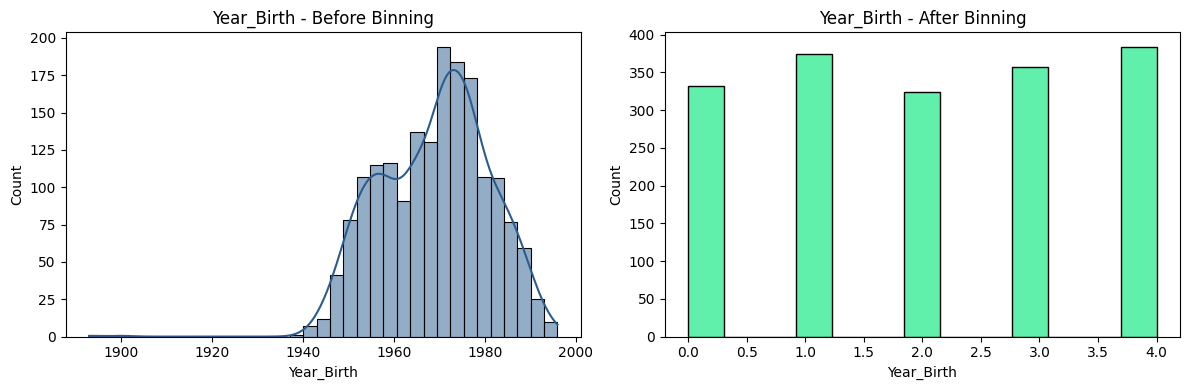

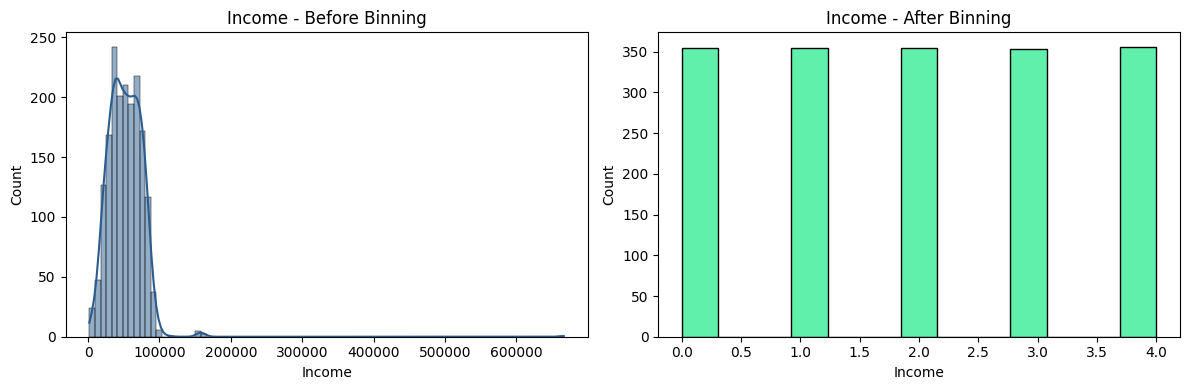

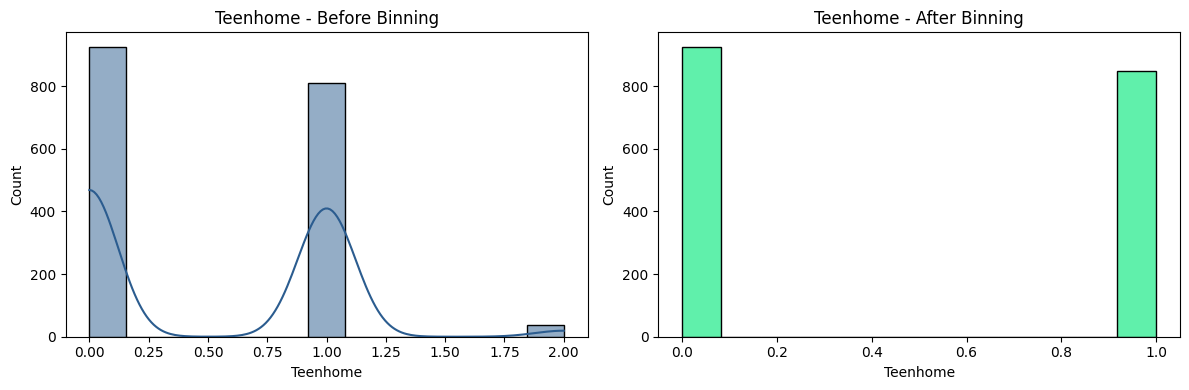

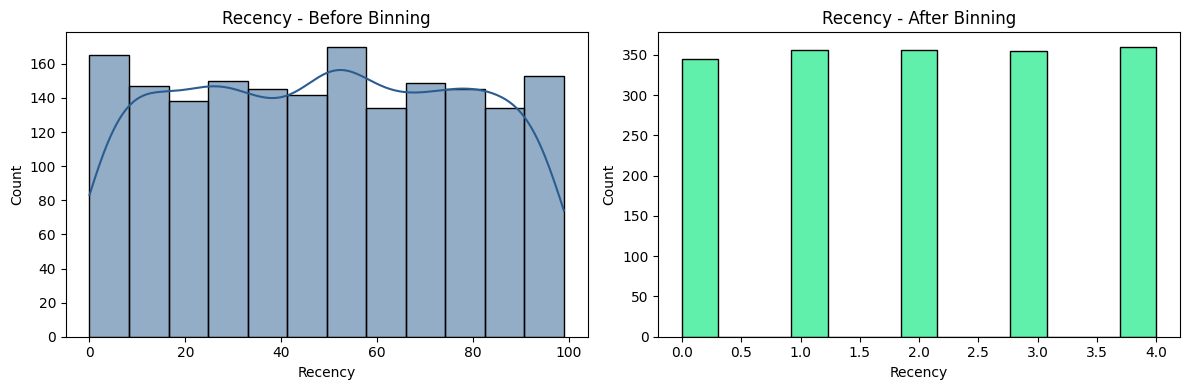

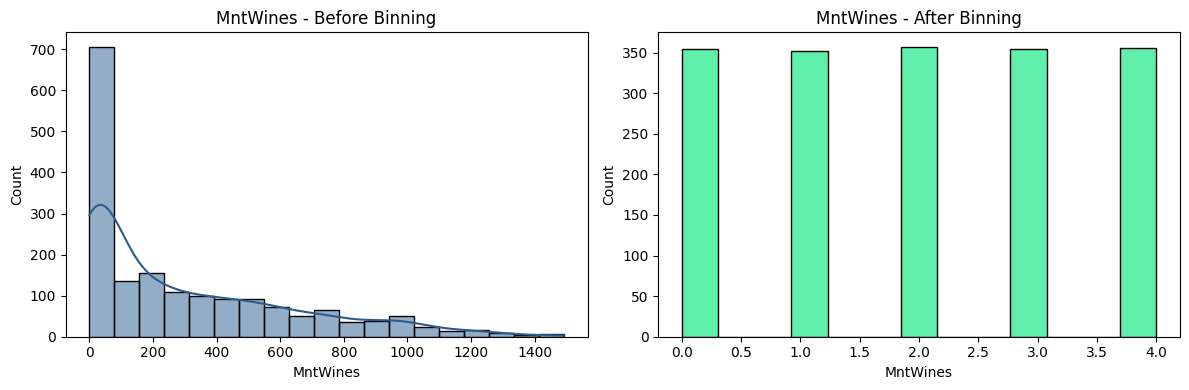

In [334]:

X_train_clean, X_test_clean, score, cv_score = discretizer(
    X, 
    y,
    n_bins=5, 
    strategy='quantile' 
)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


 MODEL PERFORMANCE (QUANTILE BINNING - 3 BINS) 
Before Binning Train/Test Accuracy : 0.7523
Before Binning 10-Fold Cross-Validation Mean: 0.7847
After Binning Train/Test Accuracy : 0.7950
After Binning 10-Fold Cross-Validation Mean: 0.7802


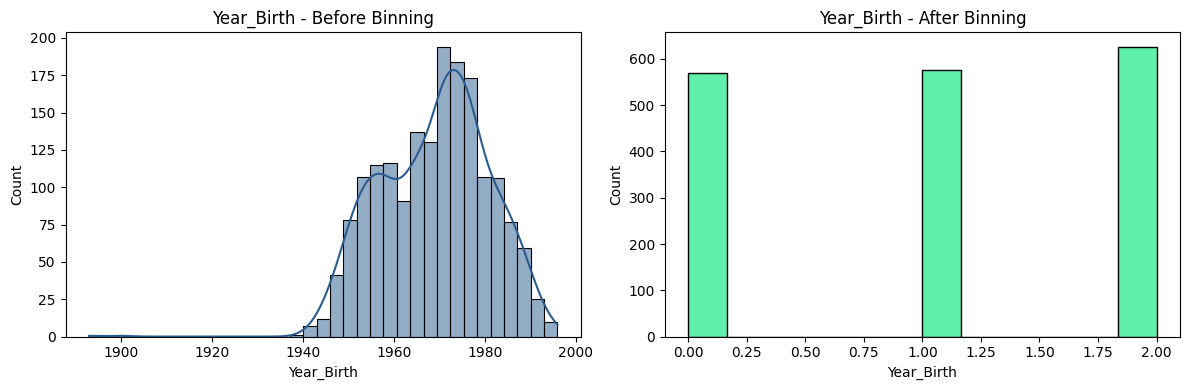

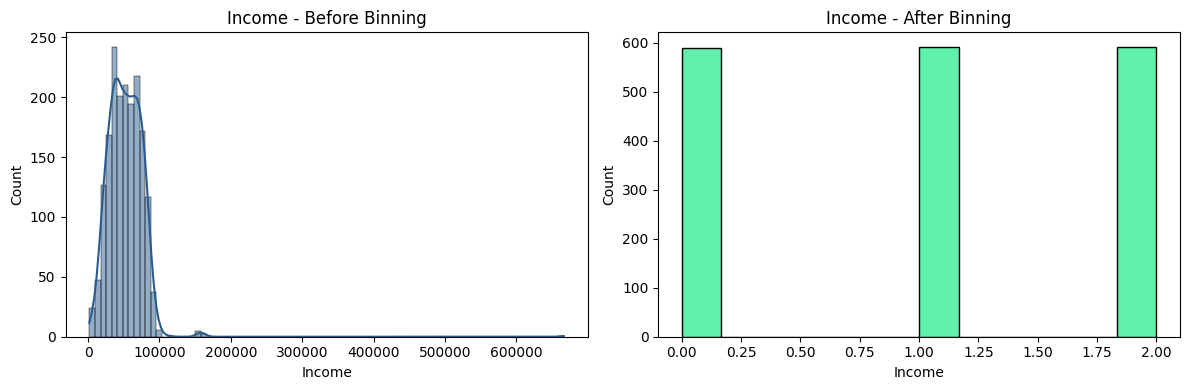

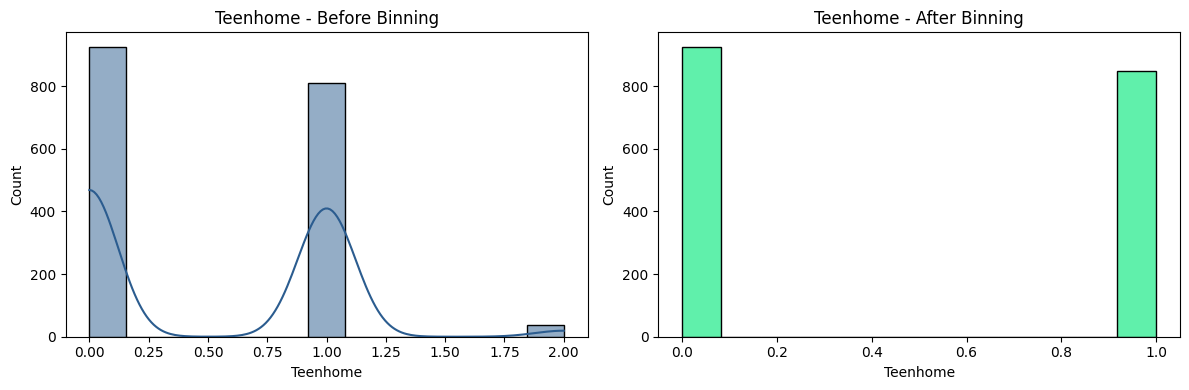

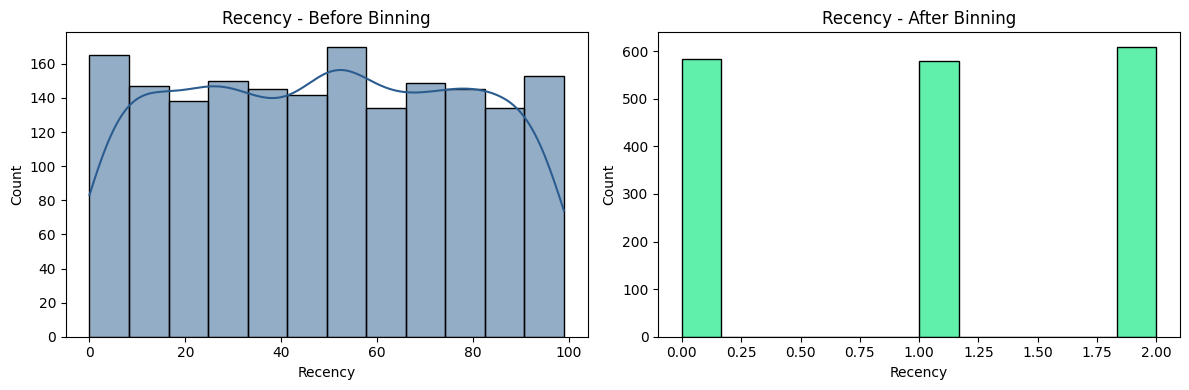

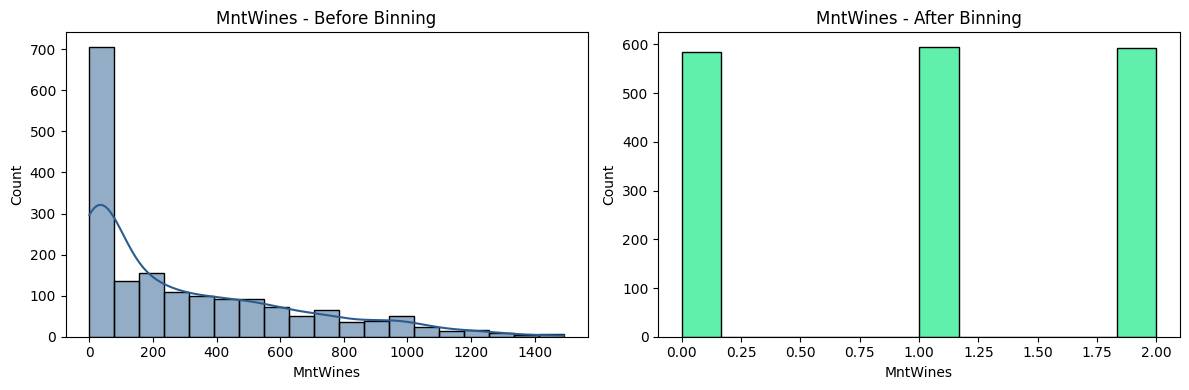

In [351]:
df = pd.read_csv('marketing_campaign-selected-columns.csv')
df.dropna(inplace=True)
X = df[['Year_Birth','Income',	'Teenhome',	'Recency','MntWines']]
y = df['Kidhome']

X_train_clean, X_test_clean, score, cv_score = discretizer(
    X, 
    y,
    n_bins=3, 
    strategy='quantile' 
)